M Riziq Sirfatullah Alfarizi

i2211266

# Decision Tree

Decision Tree adalah metode pembelajaran terawasi (supervised learning) yang digunakan untuk tugas klasifikasi dan regresi. Cara kerjanya adalah dengan membagi dataset ke dalam subset berdasarkan nilai fitur, menciptakan struktur seperti pohon dimana setiap node internal mempresentasikan "uji" pada suatu fitur, setiap cabang mempresentasikan hasil dari uji tersebut, dan setiap node daun mempresentasikan label kelas (untuk klasifikasi) atau nilai (untuk regresi).<br>
- Criterion : digunakan untuk metode pemisahan pada node (kotak), menggunakan 'gini' atau 'entropy'.<br>Entropy : mengukur ketidakpastian dalam set data, semakin rendah entropy, semakin tinggi nilai informasi yang didapat dari pemisahan.<br>
Gini : mengukur seberapa sering elemen dalam dataset salah diklasifikasikan jika dipilih secara acak.<br>
- Max_depth : mengukur kedalaman maksimal dari pohon untuk mengontrol overfitting.

# Decision Tree Classifier

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

In [98]:
wine = load_wine()
x = wine.data
y = wine.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [101]:
model_tree_1 = DecisionTreeClassifier(criterion='gini', max_depth= 3, random_state=0)

# Training time
model_tree_1.fit(x_train, y_train)

# Membuat Prediksi
y_pred = model_tree_1.predict(x_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"akurasi {akurasi * 100:.2f}%")

print('Data hasil prediksi \n', y_pred)
print('Data asli \n', y_pred)

akurasi 97.22%
Data hasil prediksi 
 [0 2 1 0 1 1 0 2 1 1 2 2 0 1 2 1 0 0 1 0 0 0 0 1 1 1 1 1 1 2 0 0 1 0 0 0]
Data asli 
 [0 2 1 0 1 1 0 2 1 1 2 2 0 1 2 1 0 0 1 0 0 0 0 1 1 1 1 1 1 2 0 0 1 0 0 0]


## Visualisasi Decision Tree


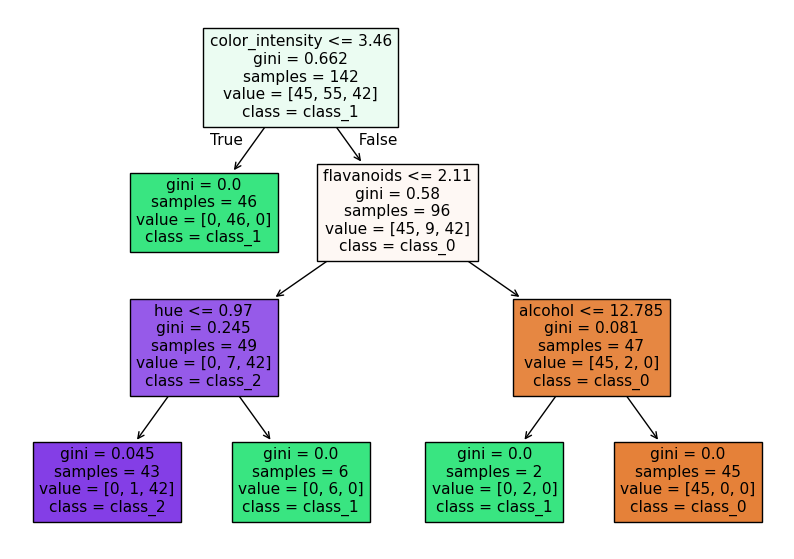

In [102]:
plt.figure(figsize = (10,7))

tree.plot_tree(model_tree_1, feature_names= wine.feature_names,
               class_names= wine.target_names, filled=True)
plt.show()

# Decision Tree Regressor

In [37]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [49]:
diabetes = load_diabetes()

x = diabetes.data[:,:2] # ngambil 2 data pertama # contoh ngambil data [:,:2,4]
y = diabetes.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

Hasil MSE = 5809.256470040991


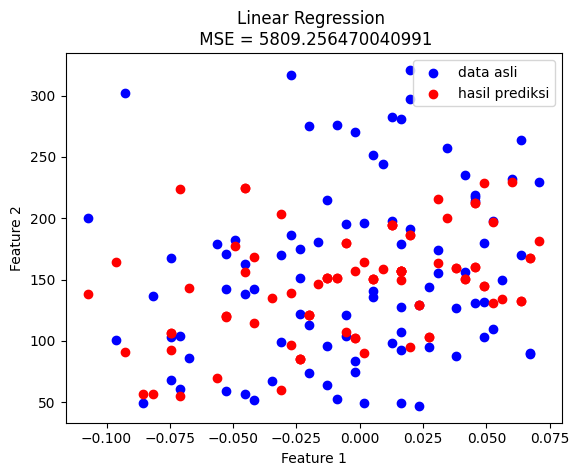

In [55]:
tree_regressor = DecisionTreeRegressor(random_state=0)

# Training time
tree_regressor.fit(x_train, y_train)

# Membuat Prediksi
y_pred = tree_regressor.predict(x_test)

#Evaluasi
MSE = mean_squared_error(y_test,y_pred)
print(f"Hasil MSE = {MSE}")

# plot

plt.scatter(x_test[:,0], y_test, color='blue', label = 'data asli')
plt.scatter(x_test[:,0],y_pred, color = 'red', label = 'hasil prediksi')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title(f'Linear Regression \n MSE = {MSE}')
plt.show()


# Support Vector Machine

Support Vector machine (SVM) adalah algoritma pemnelajaran terawasi yang digunakan untuk tugas klasifikasi dan regresi. Algoritma ini bekerja dengan menemukan hyperplane optimal (pada klasifikasi) atau garis (pada regresi) yang paling baik memisahkan data.<br><br>
Kernel:<br>
- Linear Kernel : digunakan ketika data dapat dipisahkan secara linier. Kernel ini menghitung produk dalam antara dua vektor, dan cocok untuk dataset yang dapat dipisahkan dengan garis lurus.<br>
- RBF (Radial Basis Functional kernel) : adalah kernel non-linear yang banyak digunakan dalam SVM. Kernel ini bekerja engan memetakan data ke dalam ruang dimensi yang lebih tinggi, membuat data ynag tidak dapat dipisahkan secara linier dalam ruang asli menjadi dapat dipisahkan di ruang yang lebih tinggi.<br>
- Polynomial Kernel : adalah kernel non-linear yang cocok untuk dataset yang memiliki hubungan non-linier antara fitur. Ini memungkinkan SVM untuk memisahkan data menggunakan kurva polinomial.<br>
- Sigmoid Kernel : berasal dari fungsi aktivasi sigmoid yang digunakan dalam jaringan saraf tiruan (neural networks). Ini bekerja dengan memetakan titik data ke ruang dimensi yang lebih tinggi dengan menggunakan fungsi sigmoid.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

In [93]:
from sklearn.svm import SVC
wine = load_wine()
x = wine.data
y = wine.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [94]:
svm_linear = SVC(kernel = 'linear') #'linear', 'poly', 'sigmoid', 'rbf'

# Training
svm_linear.fit(x_train, y_train)

# Membuat Prediksi
y_pred = svm_linear.predict(x_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"akurasi {akurasi * 100:.2f}%")
print('Data asli \n', y_pred)
print('Data prediksi \n', y_pred)

akurasi 97.22%
Data asli 
 [0 2 1 0 1 1 0 2 1 1 2 2 0 1 2 1 0 0 2 0 1 0 0 1 1 1 1 1 1 2 0 0 1 0 0 0]
Data prediksi 
 [0 2 1 0 1 1 0 2 1 1 2 2 0 1 2 1 0 0 2 0 1 0 0 1 1 1 1 1 1 2 0 0 1 0 0 0]


Hasil MSE = 3438.4878514921766


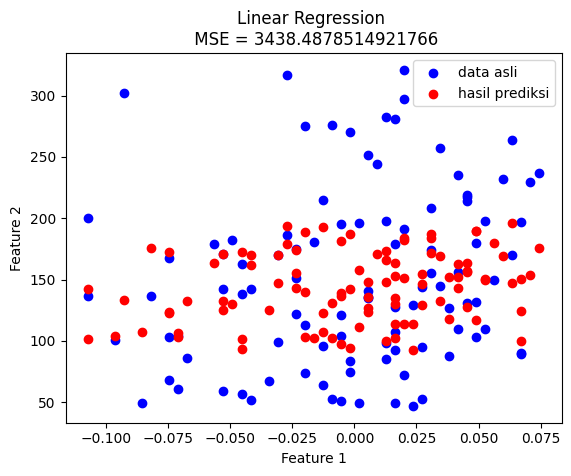

In [91]:
from sklearn.svm import SVR
diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.225, random_state=0)
svm2 = SVR(kernel = 'sigmoid') #'linear', 'poly', 'sigmoid', 'rbf'

# Training
svm2.fit(x_train, y_train)

# Membuat Prediksi
y_pred = svm2.predict(x_test)
MSE = mean_squared_error(y_test,y_pred)
print(f"Hasil MSE = {MSE}")


# plot

plt.scatter(x_test[:,0], y_test, color='blue', label = 'data asli')
plt.scatter(x_test[:,0],y_pred, color = 'red', label = 'hasil prediksi')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title(f'Linear Regression \n MSE = {MSE}')
plt.show()


#<a href="https://www.linkedin.com/in/m-riziq-sa"><img src="https://img.shields.io/badge/-© 2024 M. Riziq Sirfatullah Alfarizi-417DAC?style=for-the-badge&logoColor=white"/></a>